# Prepare data notebook

In [1]:
import sys
sys.path.append('../src/')

from data.build_intraday_and_rv import build_intraday_and_rv
from data.build_har_dataset import build_har_dataset


list_of_coins = ["ADA", "BTC", "ETH", "SOL", "XRP"] # Custom list of available coins

for coin_name in list_of_coins:
    print(f"Processing {coin_name}...")
    build_intraday_and_rv(coin_name)
    build_har_dataset(coin_name)

Processing ADA...
Raw intraday file used: ..\data\raw\ADAUSDT_binance_5min_2017_2026.csv
Daily RV saved to: ..\data\interim\daily_rv\ADA_rv.parquet
HAR dataset saved to: ..\data\processed\HAR\ADA_har.parquet
Processing BTC...
Raw intraday file used: ..\data\raw\BTCUSDT_binance_5min_2017_2026.csv
Daily RV saved to: ..\data\interim\daily_rv\BTC_rv.parquet
HAR dataset saved to: ..\data\processed\HAR\BTC_har.parquet
Processing ETH...
Raw intraday file used: ..\data\raw\ETHUSDT_binance_5min_2017_2026.csv
Daily RV saved to: ..\data\interim\daily_rv\ETH_rv.parquet
HAR dataset saved to: ..\data\processed\HAR\ETH_har.parquet
Processing SOL...
Raw intraday file used: ..\data\raw\SOLUSDT_binance_5min_2017_2026.csv
Daily RV saved to: ..\data\interim\daily_rv\SOL_rv.parquet
HAR dataset saved to: ..\data\processed\HAR\SOL_har.parquet
Processing XRP...
Raw intraday file used: ..\data\raw\XRPUSDT_binance_5min_2017_2026.csv
Daily RV saved to: ..\data\interim\daily_rv\XRP_rv.parquet
HAR dataset saved to

# See the data

In [2]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

# Optional (cleaner plots)
plt.style.use("seaborn-v0_8")

RV_DIR = Path("../data/interim/daily_rv")

In [3]:
def load_all_rv() -> pd.DataFrame:
    """
    Load all daily RV parquet files and merge them
    into a single DataFrame indexed by date.
    """

    rv_files = sorted(RV_DIR.glob("*_rv.parquet"))

    if not rv_files:
        raise FileNotFoundError("No RV files found.")

    rv_list = []

    for file in rv_files:
        coin = file.stem.replace("_rv", "")

        df = pd.read_parquet(file)
        df = df.rename(columns={"RV": f"RV_{coin}"})

        rv_list.append(df)

    # Merge on date index
    rv_df = pd.concat(rv_list, axis=1)

    rv_df.sort_index(inplace=True)

    return rv_df


rv_df = load_all_rv()

rv_df.head()

,RV_ADA,RV_BTC,RV_ETH,RV_SOL,RV_XRP
date,,,,,
2017-08-17 00:00:00+00:00,NaN,0.004322,0.008348,NaN,NaN
2017-08-18 00:00:00+00:00,NaN,0.005784,0.010477,NaN,NaN
2017-08-19 00:00:00+00:00,NaN,0.007632,0.007054,NaN,NaN
2017-08-20 00:00:00+00:00,NaN,0.003788,0.007620,NaN,NaN
2017-08-21 00:00:00+00:00,NaN,0.007837,0.014706,NaN,NaN


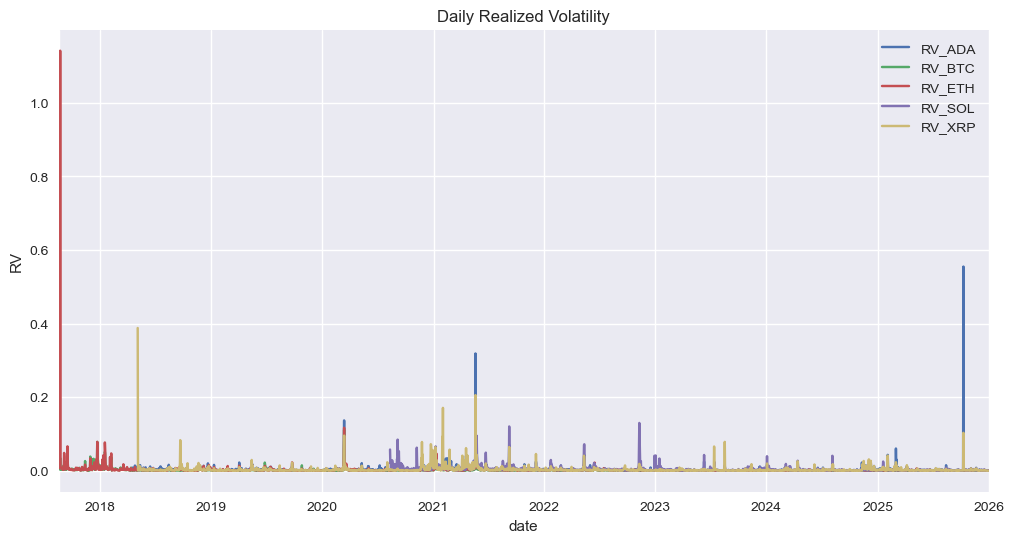

In [4]:
rv_df.plot(figsize=(12,6))
plt.title("Daily Realized Volatility")
plt.ylabel("RV")
plt.show()

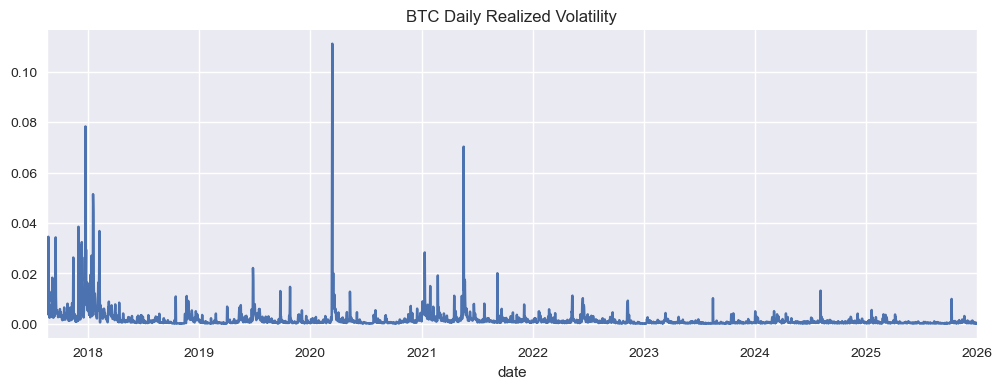

In [5]:
rv_df["RV_BTC"].plot(figsize=(12,4))
plt.title("BTC Daily Realized Volatility")
plt.show()

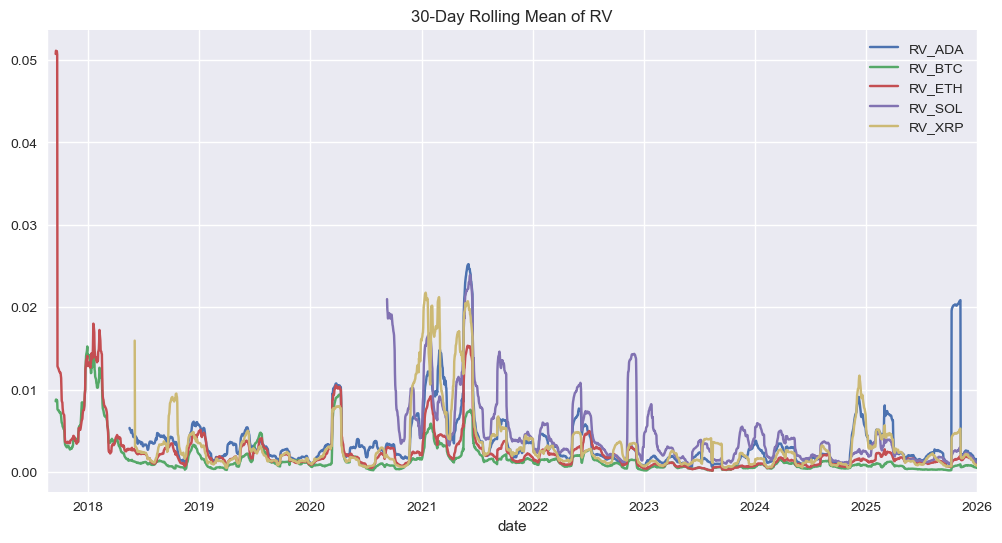

In [6]:
rv_df.rolling(30).mean().plot(figsize=(12,6))
plt.title("30-Day Rolling Mean of RV")
plt.show()

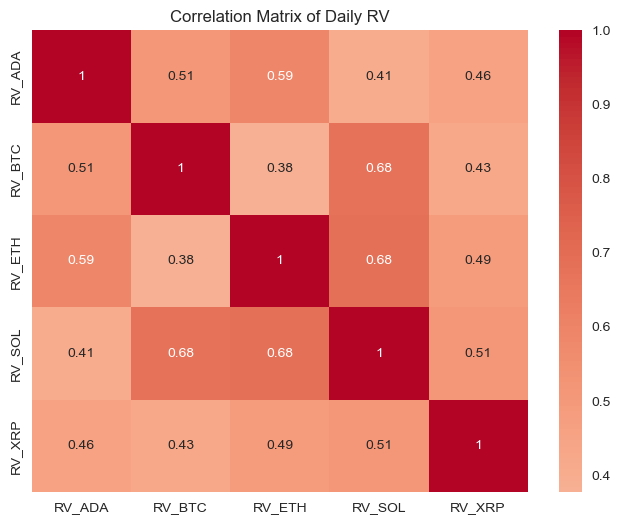

In [7]:
corr = rv_df.corr()

import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Matrix of Daily RV")
plt.show()

In [8]:
rv_df.describe()

,RV_ADA,RV_BTC,RV_ETH,RV_SOL,RV_XRP
count,2.817000e+03,3.060000e+03,3.060000e+03,1.970000e+03,2.800000e+03
mean,3.525351e-03,1.677930e-03,2.855986e-03,4.653395e-03,3.381689e-03
std,1.313276e-02,4.233760e-03,2.139753e-02,8.952715e-03,1.124464e-02
min,8.094334e-07,6.488709e-09,2.945911e-08,5.791927e-08,2.650965e-08
25%,1.026429e-03,3.477134e-04,6.279851e-04,1.291777e-03,6.724447e-04
50%,1.772662e-03,6.963876e-04,1.209890e-03,2.315915e-03,1.259739e-03
75%,3.382250e-03,1.511978e-03,2.396134e-03,4.569653e-03,2.696953e-03
max,5.550513e-01,1.112067e-01,1.141988e+00,1.369362e-01,3.880236e-01


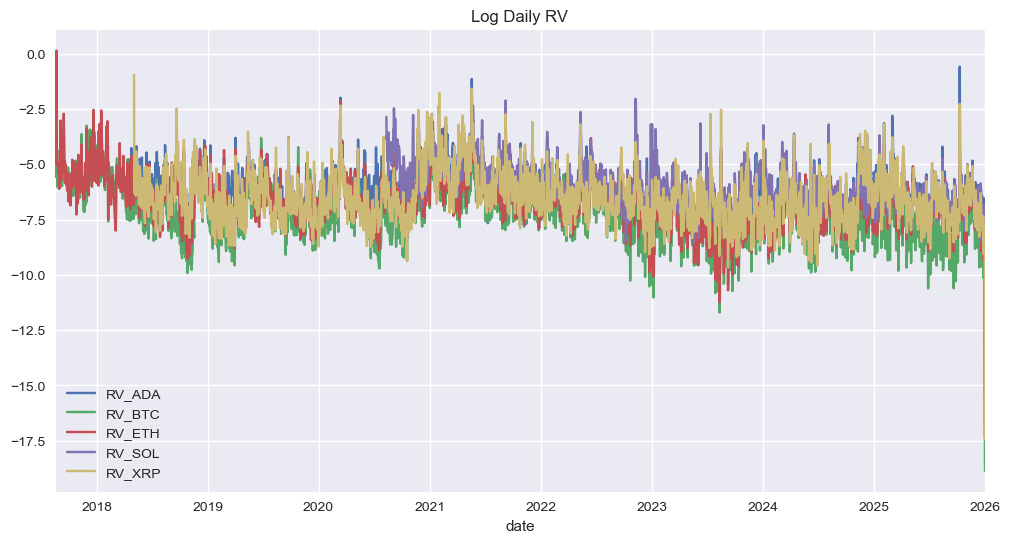

In [9]:
import numpy as np

log_rv = rv_df.apply(lambda x: np.log(x))
log_rv.plot(figsize=(12,6))
plt.title("Log Daily RV")
plt.show()

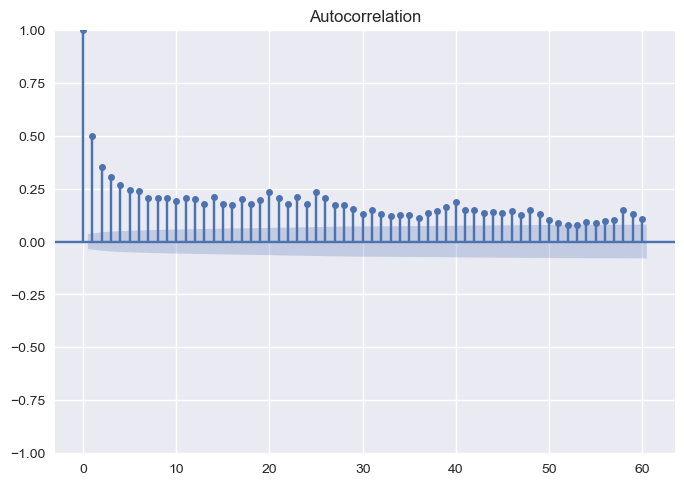

In [10]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(rv_df["RV_BTC"], lags=60)
plt.show()